# Notebook Overview

**Purpose:**
This notebook performs a structured out-of-sample evaluation of previously trained LSTM and xLSTM models across multiple equities, forecast horizons, and feature configurations. It restores the best saved model artifacts per configuration, reproduces the original test-set preprocessing pipeline, computes denormalised test metrics (RMSE and R²), and generates publication-ready comparison figures and tables.

**Inputs:**
- Sentiment-augmented time series CSVs per ticker: `../data/ts_with_sentiment/{TICKER}_ts_with_sentiment.csv` (expects `Close`, optional sentiment features, and the corresponding date index handled by `PrepAndDataLoader`).
- Saved best-model artifacts per ticker and configuration:
  - Checkpoints: `../data/best_models/{TICKER}/{MODEL}_H{H}_F{F}_{TICKER}.pt`
  - Config files: `../data/best_models/{TICKER}/{MODEL}_H{H}_F{F}_{TICKER}.config.json`
- Evaluation configuration parameters:
  - Tick list, feature sets (F=1 vs. F=5), horizons, window size, stride, normalisation method, batch size, global seed.
- Local plotting style settings (dark theme) applied via Matplotlib `rcParams`.

**Outputs:**
- Per-configuration comparison plots (True vs. LSTM vs. xLSTM) saved for each ticker:
  - PDF: `../data/Figures/Plots/{TICKER}/COMPARE_H{H}_F{F}_{TICKER}.pdf`
  - PNG: `../data/Figures/Plots/{TICKER}/COMPARE_H{H}_F{F}_{TICKER}.png`
- Per-ticker result tables (CSV and LaTeX) summarising test RMSE and R²:
  - `../data/Figures/Tables/{TICKER}/results_{TICKER}.csv`
  - `../data/Figures/Tables/{TICKER}/results_{TICKER}.tex`
- Per-ticker Error Reduction (ER) tables quantifying RMSE(LSTM) − RMSE(xLSTM):
  - `../data/Figures/Tables/{TICKER}/er_{TICKER}.csv`
  - `../data/Figures/Tables/{TICKER}/er_{TICKER}.tex`
- Global summary exports across all assets:
  - `../data/Figures/Tables/_global/results_all_assets.csv`
  - `../data/Figures/Tables/_global/results_all_assets.tex`
  - Optional failures log: `../data/Figures/Tables/_global/failures.csv`

**Process Summary:**
For each ticker, the notebook iterates over model types (LSTM, xLSTM), feature sets (price-only vs. price plus sentiment), and horizons. For each configuration it (i) reloads the saved checkpoint and configuration, (ii) reconstructs the test set using the same preprocessing, windowing, stride, and normalisation settings as training, (iii) generates multi-horizon predictions, (iv) denormalises predictions and targets back to the original price level, and (v) computes test RMSE and R² on the denormalised scale. Results are collected into per-ticker and global tables, Error Reduction metrics are computed by aligning LSTM and xLSTM rows, and comparison plots are produced for consistent visual inspection of model performance.

**Workflow Notes:**
- The notebook assumes that saved artifacts exist for every `(ticker, model_type, horizon, n_features)` combination; missing checkpoints or configs are recorded as failures and excluded from plots/tables.
- Denormalisation relies on cached base values produced during `prepare_data_from_prep`; therefore, the normalisation method and preprocessing parameters must remain consistent with the training pipeline.
- Plots are generated for the final horizon step (t+H) when `stride = 1`, enabling a consistent comparison across horizons while preserving chronological alignm


In [2]:

# =========================
# Imports
# =========================
import os
import json
from pathlib import Path
from typing import Dict, Any, List, Literal, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, root_mean_squared_error

import torch

from model_wrapper import Model, set_global_seed
from data_prep import PrepAndDataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[Info] Using device: {DEVICE}")


[Info] Using device: cuda


In [7]:

# =========================
# Global configuration (must match training)
# =========================

TICKERS: List[str] = ["AAPL", "DIS", "IBM", "INTC", "JNJ", "JPM", "KO", "MSFT", "NKE", "V"]

DATA_DIR = Path("../data/ts_with_sentiment")
FILE_PATTERN = "{ticker}_ts_with_sentiment.csv"
TARGET_COL: str = "Close"
TRAIN_SPLIT: float = 0.6
VAL_SPLIT: float = 0.2

FEATURE_SETS: Dict[str, List[str]] = {
    "price_only": ["Close"],  # F=1
    "price_plus_sentiment": ["Close", "pos_mean", "neut_mean", "neg_mean", "news_count"],  # F=5
}
FEATURE_KEYS_ORDER = ["price_only", "price_plus_sentiment"]

WINDOW_SIZE: int = 60
HORIZONS: List[int] = [1, 3, 5, 10, 15]
STRIDE: int = 1

NORMALISE: bool = True
NORM_METHOD: Literal["percentage", "minmax"] = "percentage"

BATCH_SIZE: int = 128
MODEL_TYPES: List[str] = ["LSTM", "xLSTM"]

GLOBAL_SEED: int = 42

BEST_MODELS_ROOT = Path("../data/best_models")
FIG_PLOTS_ROOT = Path("../data/Figures/Plots")
FIG_TABLES_ROOT = Path("../data/Figures/Tables")

FIG_PLOTS_ROOT.mkdir(parents=True, exist_ok=True)
FIG_TABLES_ROOT.mkdir(parents=True, exist_ok=True)

print("[Info] Configuration loaded.")


[Info] Configuration loaded.


In [4]:

# =========================
# Plot style (dark layout like your portfolio plot)
# =========================

def apply_plot_style_dark() -> None:
    plt.rcParams.update({
        "figure.facecolor": "#232733",
        "axes.facecolor": "#232733",
        "axes.edgecolor": "#9aa4b2",
        "axes.labelcolor": "#e6e6e6",
        "xtick.color": "#e6e6e6",
        "ytick.color": "#e6e6e6",
        "grid.color": "#3b4252",
        "grid.linestyle": "-",
        "grid.linewidth": 0.8,
        "legend.frameon": True,
        "legend.facecolor": "#232733",
        "legend.edgecolor": "#9aa4b2",
        "text.color": "#e6e6e6",
        "font.size": 11,
        "savefig.facecolor": "#232733",
        "savefig.edgecolor": "#232733",
    })

apply_plot_style_dark()

COLOR_TRUE  = "#1f77b4"  # blue
COLOR_LSTM  = "#d62728"  # red
COLOR_XLSTM = "#2ca02c"  # green


In [11]:

# =========================
# Helpers
# =========================

def ensure_reproducible(seed: int) -> None:
    set_global_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def make_base_name(model_type: str, horizon: int, n_features: int, ticker: str) -> str:
    return f"{model_type}_H{horizon}_F{n_features}_{ticker}"


def load_saved_artifacts(ticker: str, model_type: str, horizon: int, n_features: int) -> Tuple[Path, Dict[str, Any]]:
    model_dir = BEST_MODELS_ROOT / ticker
    name = make_base_name(model_type, horizon, n_features, ticker)

    ckpt = model_dir / f"{name}.pt"
    cfgp = model_dir / f"{name}.config.json"

    if not ckpt.is_file():
        raise FileNotFoundError(f"Missing checkpoint: {ckpt}")
    if not cfgp.is_file():
        raise FileNotFoundError(f"Missing config: {cfgp}")

    with open(cfgp, "r", encoding="utf-8") as f:
        cfg = json.load(f)

    return ckpt, cfg


def prepare_test_data(ticker: str, feature_cols: List[str], horizon: int) -> Dict[str, Any]:
    csv_path = DATA_DIR / FILE_PATTERN.format(ticker=ticker)
    if not csv_path.is_file():
        raise FileNotFoundError(f"Missing CSV: {csv_path}")

    prep = PrepAndDataLoader(
        filename=str(csv_path),
        training_split=TRAIN_SPLIT,
        validation_split=VAL_SPLIT,
        cols=feature_cols,
        target_col=TARGET_COL,
    )

    tmp_model = Model()
    _, _, _, _, X_te, y_te = tmp_model.prepare_data_from_prep(
        prep,
        normalise=NORMALISE,
        window_size=WINDOW_SIZE,
        prediction_range=horizon,
        norm_method=NORM_METHOD,
        stride=STRIDE,
        verbose=0,
    )

    dates_te = prep.get_prediction_dates(
        "test",
        window_size=WINDOW_SIZE,
        prediction_range=horizon,
        stride=STRIDE,
    )  # [N, H]

    baseT_te = tmp_model._cache.get("baseT_te", None)

    return {"prep": prep, "X_te": X_te, "y_te": y_te, "dates_te": dates_te, "baseT_te": baseT_te}


def denormalise_to_level(
    prep: PrepAndDataLoader,
    y_true_scaled: np.ndarray,   # [N, H, 1]
    y_pred_scaled: np.ndarray,   # [N, H]
    baseT_te: Optional[np.ndarray],
) -> Tuple[np.ndarray, np.ndarray]:
    y_pred_scaled_3d = y_pred_scaled[..., None]  # [N, H, 1]
    y_true_scaled_3d = y_true_scaled             # [N, H, 1]

    if not NORMALISE:
        return y_true_scaled.squeeze(-1), y_pred_scaled

    if NORM_METHOD == "percentage":
        if baseT_te is None:
            raise ValueError("baseT_te is required for percentage normalisation.")
        y_pred_level = prep.denormalise(
            y_pred_scaled_3d, method="percentage", base_values=baseT_te, normalise=True
        ).squeeze(-1)
        y_true_level = prep.denormalise(
            y_true_scaled_3d, method="percentage", base_values=baseT_te, normalise=True
        ).squeeze(-1)
        return y_true_level, y_pred_level

    if NORM_METHOD == "minmax":
        y_pred_level = prep.denormalise(
            y_pred_scaled_3d, method="minmax", base_values=None, normalise=True
        ).squeeze(-1)
        y_true_level = prep.denormalise(
            y_true_scaled_3d, method="minmax", base_values=None, normalise=True
        ).squeeze(-1)
        return y_true_level, y_pred_level

    raise ValueError(f"Unknown NORM_METHOD={NORM_METHOD}")


def compute_metrics_level(y_true_level: np.ndarray, y_pred_level: np.ndarray) -> Tuple[float, float]:
    y_true_flat = y_true_level.reshape(-1)
    y_pred_flat = y_pred_level.reshape(-1)
    rmse = float(root_mean_squared_error(y_true_flat, y_pred_flat))
    r2 = float(r2_score(y_true_flat, y_pred_flat))
    return rmse, r2


def predict_saved_model(
    ticker: str,
    model_type: str,
    horizon: int,
    feature_set_name: str,
    feature_cols: List[str],
) -> Dict[str, Any]:
    n_features = len(feature_cols)

    data = prepare_test_data(ticker, feature_cols, horizon)
    prep = data["prep"]
    X_te = data["X_te"]
    y_te = data["y_te"]
    dates_te = data["dates_te"]
    baseT_te = data["baseT_te"]

    ckpt_path, cfg = load_saved_artifacts(ticker, model_type, horizon, n_features)

    cfg = dict(cfg)
    cfg["window_size"] = int(WINDOW_SIZE)
    cfg["horizon"] = int(horizon)
    cfg["n_features"] = int(X_te.shape[-1])

    ensure_reproducible(GLOBAL_SEED)

    m = Model()
    m.build(config=cfg, model_type=model_type)
    m.load(str(ckpt_path))

    y_pred_scaled = m.predict_multi_horizon(X_te, batch_size=BATCH_SIZE, verbose=0)
    y_true_level, y_pred_level = denormalise_to_level(prep, y_te, y_pred_scaled, baseT_te)

    rmse, r2 = compute_metrics_level(y_true_level, y_pred_level)

    return {
        "asset": ticker,
        "model_type": model_type,
        "feature_set": feature_set_name,
        "n_features": n_features,
        "horizon": horizon,
        "test_rmse_level": rmse,
        "test_r2_level": r2,
        "dates_te": dates_te,
        "y_true_level": y_true_level,
        "y_pred_level": y_pred_level,
    }


def plot_compare_predictions(
    ticker: str,
    horizon: int,
    n_features: int,
    dates_te: np.ndarray,        # [N, H]
    y_true_level: np.ndarray,    # [N, H]
    y_lstm_level: np.ndarray,    # [N, H]
    y_xlstm_level: np.ndarray,   # [N, H]
    rmse_lstm: float,
    rmse_xlstm: float,
    r2_lstm: float,
    r2_xlstm: float,
    save_pdf: Path,
    save_png: Path,
) -> None:
    apply_plot_style_dark()

    h_idx = horizon - 1
    dates = dates_te[:, h_idx]

    plt.figure(figsize=(12, 5))

    plt.plot(dates, y_true_level[:, h_idx], label="True", color=COLOR_TRUE, linewidth=2.3)

    plt.plot(
        dates, y_lstm_level[:, h_idx],
        label=f"LSTM (RMSE={rmse_lstm:.3f}, R²={r2_lstm:.3f})",
        color=COLOR_LSTM, linestyle="--", linewidth=1.9
    )

    plt.plot(
        dates, y_xlstm_level[:, h_idx],
        label=f"xLSTM (RMSE={rmse_xlstm:.3f}, R²={r2_xlstm:.3f})",
        color=COLOR_XLSTM, linestyle="--", linewidth=1.9
    )

    plt.title(f"{ticker} – Prediction Comparison | H={horizon} | F={n_features} – TEST")
    plt.xlabel("Date")
    plt.ylabel("Price")

    plt.legend()
    plt.grid(True)
    plt.gcf().autofmt_xdate()
    plt.tight_layout()

    plt.savefig(save_pdf, format="pdf")
    plt.savefig(save_png, format="png", dpi=300)
    plt.close()


def save_tables_for_ticker(ticker: str, df_results: pd.DataFrame, df_er: pd.DataFrame) -> None:
    out_dir = FIG_TABLES_ROOT / ticker
    out_dir.mkdir(parents=True, exist_ok=True)

    results_csv = out_dir / f"results_{ticker}.csv"
    results_tex = out_dir / f"results_{ticker}.tex"

    df_results.to_csv(results_csv, index=False)
    df_results.to_latex(
        results_tex,
        index=False,
        float_format="%.4f",
        longtable=True,
        caption=f"Test results for {ticker} (RMSE and R\\^2 on denormalised level).",
        label=f"tab:results_{ticker}",
    )

    er_csv = out_dir / f"er_{ticker}.csv"
    er_tex = out_dir / f"er_{ticker}.tex"

    df_er.to_csv(er_csv, index=False)
    df_er.to_latex(
        er_tex,
        index=False,
        float_format="%.4f",
        longtable=True,
        caption=f"Error Reduction (ER) for {ticker}: RMSE(LSTM) − RMSE(xLSTM).",
        label=f"tab:er_{ticker}",
    )

    print(f"[Saved] {results_csv}")
    print(f"[Saved] {results_tex}")
    print(f"[Saved] {er_csv}")
    print(f"[Saved] {er_tex}")


In [10]:

ensure_reproducible(GLOBAL_SEED)

ticker = "AAPL"
horizon = 1
feature_set_name = "price_only"
feature_cols = FEATURE_SETS[feature_set_name]
n_features = len(feature_cols)

lstm_res  = predict_saved_model(ticker, "LSTM",  horizon, feature_set_name, feature_cols)
xlstm_res = predict_saved_model(ticker, "xLSTM", horizon, feature_set_name, feature_cols)

print(f"[LSTM ] RMSE={lstm_res['test_rmse_level']:.6f} | R²={lstm_res['test_r2_level']:.4f}")
print(f"[xLSTM] RMSE={xlstm_res['test_rmse_level']:.6f} | R²={xlstm_res['test_r2_level']:.4f}")

plot_dir = FIG_PLOTS_ROOT / ticker
plot_dir.mkdir(parents=True, exist_ok=True)

name = f"COMPARE_H{horizon}_F{n_features}_{ticker}"
plot_pdf = plot_dir / f"{name}.pdf"
plot_png = plot_dir / f"{name}.png"

plot_compare_predictions(
    ticker=ticker,
    horizon=horizon,
    n_features=n_features,
    dates_te=lstm_res["dates_te"],
    y_true_level=lstm_res["y_true_level"],
    y_lstm_level=lstm_res["y_pred_level"],
    y_xlstm_level=xlstm_res["y_pred_level"],
    rmse_lstm=lstm_res["test_rmse_level"],
    rmse_xlstm=xlstm_res["test_rmse_level"],
    r2_lstm=lstm_res["test_r2_level"],
    r2_xlstm=xlstm_res["test_r2_level"],
    save_pdf=plot_pdf,
    save_png=plot_png,
)

print(f"[Saved] {plot_pdf}")
print(f"[Saved] {plot_png}")


[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=1
  LSTM layers=2
  Trainable params: 50,497
[Model] Loaded weights from: ..\data\best_models\AAPL\LSTM_H1_F1_AAPL.pt
[Model] xLSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=1
  xLSTM blocks=2, sLSTM at=[1]
  Trainable params: 55,811
[Model] Loaded weights from: ..\data\best_models\AAPL\xLSTM_H1_F1_AAPL.pt
[LSTM ] RMSE=2.931247 | R²=0.9913
[xLSTM] RMSE=2.963845 | R²=0.9911
[Saved] ..\data\Figures\Plots\AAPL\COMPARE_H1_F1_AAPL.pdf
[Saved] ..\data\Figures\Plots\AAPL\COMPARE_H1_F1_AAPL.png


<>:130: SyntaxWarning: invalid escape sequence '\^'
<>:130: SyntaxWarning: invalid escape sequence '\^'
C:\Users\juli\AppData\Local\Temp\ipykernel_23580\250298238.py:130: SyntaxWarning: invalid escape sequence '\^'
  caption="Test results for all assets (RMSE and R\^2 on denormalised level).",



[1/200] AAPL | LSTM | price_only | H=1
[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=1
  LSTM layers=2
  Trainable params: 50,497
[Model] Loaded weights from: ..\data\best_models\AAPL\LSTM_H1_F1_AAPL.pt

[2/200] AAPL | LSTM | price_only | H=3
[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=128 | horizon=3
  LSTM layers=4
  Trainable params: 463,747
[Model] Loaded weights from: ..\data\best_models\AAPL\LSTM_H3_F1_AAPL.pt

[3/200] AAPL | LSTM | price_only | H=5
[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=5
  LSTM layers=1
  Trainable params: 17,477
[Model] Loaded weights from: ..\data\best_models\AAPL\LSTM_H5_F1_AAPL.pt

[4/200] AAPL | LSTM | price_only | H=10
[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=128 | horizon=10
  LSTM layers=1
  Trainable params: 68,362
[Model] Loaded weights from: ..\data\best_models\AAPL\LSTM_H10_F1_AAPL.pt

[5/200] AAPL | LSTM | price_only | H=15
[Model] LSTM 

,asset,model_type,feature_set,n_features,horizon,test_rmse_level,test_r2_level
0,AAPL,LSTM,price_only,1,1,2.931247,0.991299
1,AAPL,LSTM,price_only,1,3,4.205807,0.982047
2,AAPL,LSTM,price_only,1,5,5.092688,0.973614
3,AAPL,LSTM,price_only,1,10,6.980505,0.950283
4,AAPL,LSTM,price_only,1,15,9.086840,0.915563
5,AAPL,LSTM,price_plus_sentiment,5,1,2.987633,0.990961
6,AAPL,LSTM,price_plus_sentiment,5,3,4.679686,0.977774
7,AAPL,LSTM,price_plus_sentiment,5,5,5.501644,0.969206
8,AAPL,LSTM,price_plus_sentiment,5,10,8.042494,0.934005
9,AAPL,LSTM,price_plus_sentiment,5,15,9.726565,0.903255


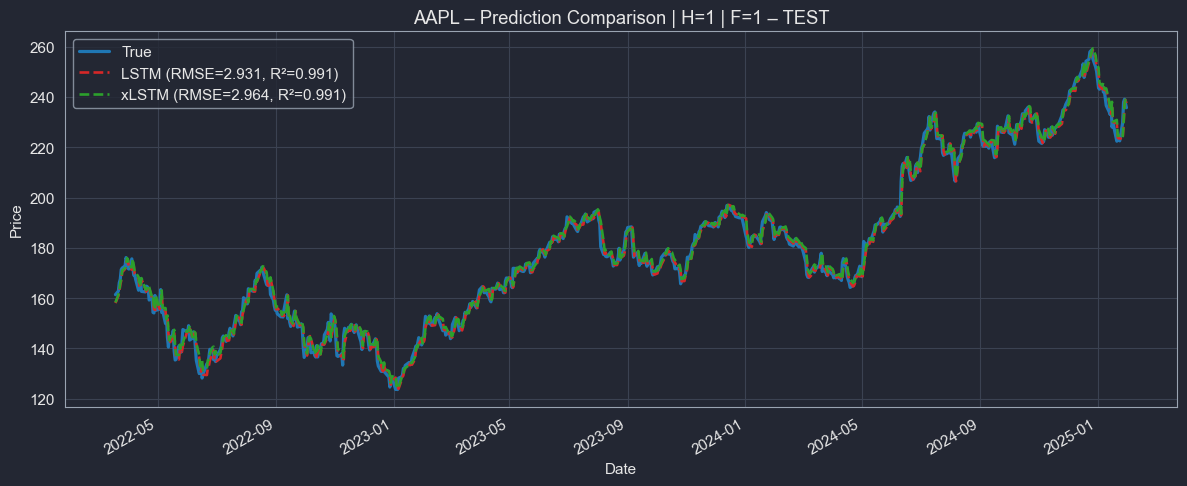

In [12]:

ensure_reproducible(GLOBAL_SEED)

all_rows: List[Dict[str, Any]] = []
failures: List[Dict[str, Any]] = []

total_jobs = len(TICKERS) * len(MODEL_TYPES) * len(FEATURE_SETS) * len(HORIZONS)
job_i = 0

for ticker in TICKERS:
    # ---------- Collect metrics ----------
    for model_type in MODEL_TYPES:
        for feature_set_name in FEATURE_KEYS_ORDER:
            feature_cols = FEATURE_SETS[feature_set_name]
            for horizon in HORIZONS:
                job_i += 1
                tag = f"{ticker} | {model_type} | {feature_set_name} | H={horizon}"
                print(f"\n[{job_i}/{total_jobs}] {tag}")

                try:
                    res = predict_saved_model(
                        ticker=ticker,
                        model_type=model_type,
                        horizon=horizon,
                        feature_set_name=feature_set_name,
                        feature_cols=feature_cols,
                    )

                    all_rows.append({
                        "asset": res["asset"],
                        "model_type": res["model_type"],
                        "feature_set": res["feature_set"],
                        "n_features": res["n_features"],
                        "horizon": res["horizon"],
                        "test_rmse_level": res["test_rmse_level"],
                        "test_r2_level": res["test_r2_level"],
                    })

                except Exception as e:
                    print(f"[FAIL] {tag}: {e}")
                    failures.append({
                        "asset": ticker,
                        "model_type": model_type,
                        "feature_set": feature_set_name,
                        "n_features": len(feature_cols),
                        "horizon": horizon,
                        "error": str(e),
                    })

    # ---------- Per-ticker tables ----------
    df_t = pd.DataFrame([r for r in all_rows if r["asset"] == ticker])
    if df_t.empty:
        print(f"[WARN] No successful results for {ticker}. Skipping plots/tables.")
        continue

    df_t = df_t.sort_values(
        by=["asset", "model_type", "feature_set", "n_features", "horizon"],
        ascending=[True, True, True, True, True],
    ).reset_index(drop=True)

    # ER
    df_l = df_t[df_t["model_type"] == "LSTM"][
        ["feature_set", "n_features", "horizon", "test_rmse_level", "test_r2_level"]
    ].rename(columns={"test_rmse_level": "rmse_lstm", "test_r2_level": "r2_lstm"})

    df_x = df_t[df_t["model_type"] == "xLSTM"][
        ["feature_set", "n_features", "horizon", "test_rmse_level", "test_r2_level"]
    ].rename(columns={"test_rmse_level": "rmse_xlstm", "test_r2_level": "r2_xlstm"})

    df_er = df_l.merge(df_x, on=["feature_set", "n_features", "horizon"], how="inner")
    df_er["er_rmse"] = df_er["rmse_lstm"] - df_er["rmse_xlstm"]
    df_er = df_er.sort_values(by=["feature_set", "n_features", "horizon"]).reset_index(drop=True)

    save_tables_for_ticker(ticker, df_t, df_er)

    # ---------- Per-ticker compare plots (per config) ----------
    plot_dir = FIG_PLOTS_ROOT / ticker
    plot_dir.mkdir(parents=True, exist_ok=True)

    for feature_set_name in FEATURE_KEYS_ORDER:
        feature_cols = FEATURE_SETS[feature_set_name]
        n_features = len(feature_cols)

        for horizon in HORIZONS:
            try:
                lstm_res  = predict_saved_model(ticker, "LSTM",  horizon, feature_set_name, feature_cols)
                xlstm_res = predict_saved_model(ticker, "xLSTM", horizon, feature_set_name, feature_cols)

                name = f"COMPARE_H{horizon}_F{n_features}_{ticker}"
                plot_pdf = plot_dir / f"{name}.pdf"
                plot_png = plot_dir / f"{name}.png"

                plot_compare_predictions(
                    ticker=ticker,
                    horizon=horizon,
                    n_features=n_features,
                    dates_te=lstm_res["dates_te"],
                    y_true_level=lstm_res["y_true_level"],
                    y_lstm_level=lstm_res["y_pred_level"],
                    y_xlstm_level=xlstm_res["y_pred_level"],
                    rmse_lstm=lstm_res["test_rmse_level"],
                    rmse_xlstm=xlstm_res["test_rmse_level"],
                    r2_lstm=lstm_res["test_r2_level"],
                    r2_xlstm=xlstm_res["test_r2_level"],
                    save_pdf=plot_pdf,
                    save_png=plot_png,
                )

            except Exception as e:
                print(f"[WARN] Plot failed for {ticker} {feature_set_name} H={horizon}: {e}")

print("\n=========================")
print(f"[Done] Successful rows: {len(all_rows)}")
print(f"[Done] Failures:       {len(failures)}")

# Global summaries
global_dir = FIG_TABLES_ROOT / "_global"
global_dir.mkdir(parents=True, exist_ok=True)

df_all = pd.DataFrame(all_rows).sort_values(
    by=["asset", "model_type", "feature_set", "n_features", "horizon"],
    ascending=[True, True, True, True, True],
).reset_index(drop=True)

df_all.to_csv(global_dir / "results_all_assets.csv", index=False)
df_all.to_latex(
    global_dir / "results_all_assets.tex",
    index=False,
    float_format="%.4f",
    longtable=True,
    caption="Test results for all assets (RMSE and R\^2 on denormalised level).",
    label="tab:results_all_assets",
)

df_fail = pd.DataFrame(failures)
if not df_fail.empty:
    df_fail.to_csv(global_dir / "failures.csv", index=False)

print(f"[Saved] {global_dir / 'results_all_assets.csv'}")
print(f"[Saved] {global_dir / 'results_all_assets.tex'}")
if not df_fail.empty:
    print(f"[Saved] {global_dir / 'failures.csv'}")

df_all.head(20)
